In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [51]:
pairwise_file = "/content/drive/MyDrive/pairwise_distances.xlsx"
adjacency_file = "/content/drive/MyDrive/adjacency_matrix.csv"

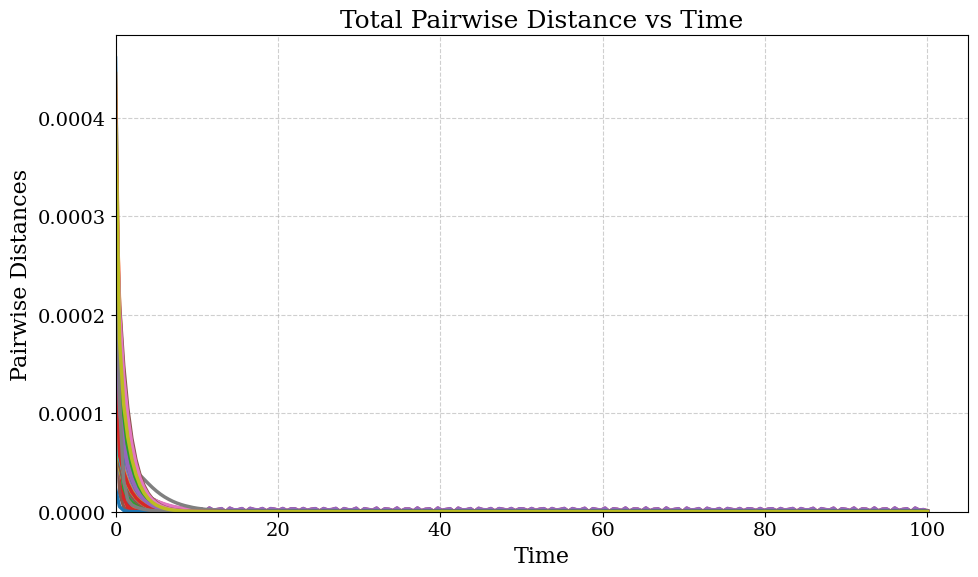

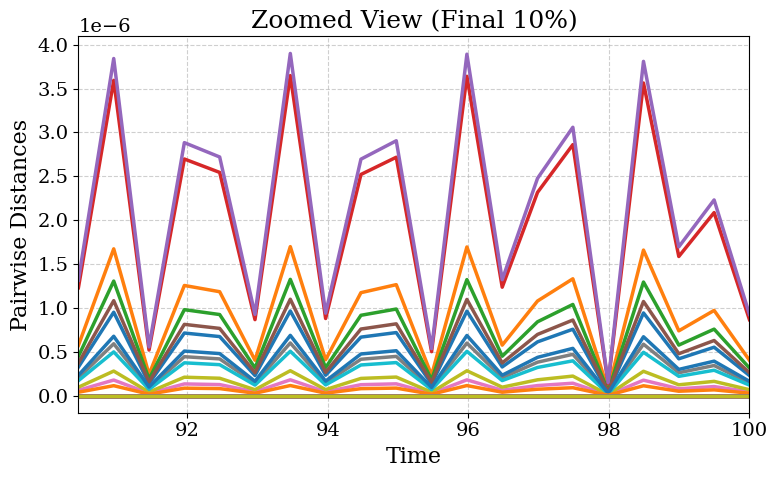

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Load Data
# -----------------------
df = pd.read_excel(pairwise_file, header=0)

time = df.iloc[:, 0].values
pairwise_distances = df.iloc[:, 1:]

# -----------------------
# Publication Styling
# -----------------------
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 10,
    "lines.linewidth": 2.5
})

# ======================================================
# 1️⃣ FULL PLOT
# ======================================================

plt.figure(figsize=(10,6))

for column in pairwise_distances.columns:
    plt.plot(time, pairwise_distances[column])

plt.xlabel("Time")
plt.ylabel("Pairwise Distances")
plt.title("Total Pairwise Distance vs Time")

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig("pairwise_distances_full.eps", format="eps", bbox_inches="tight")
plt.show()


# ======================================================
# 2️⃣ ZOOMED-IN END REGION
# ======================================================

# Zoom into last 10%
zoom_fraction = 0.10
start_index = int((1 - zoom_fraction) * len(time))

time_zoom = time[start_index:]
data_zoom = pairwise_distances.iloc[start_index:]

# Detect bounds
y_max = data_zoom.max().max()
y_min = data_zoom.min().min()

margin = 0.05 * (y_max - y_min if y_max != y_min else y_max)

plt.figure(figsize=(8,5))

for column in data_zoom.columns:
    plt.plot(time_zoom, data_zoom[column])

plt.xlabel("Time")
plt.ylabel("Pairwise Distances")
plt.title("Zoomed View (Final 10%)")

plt.xlim(time_zoom[0], time_zoom[-1])
plt.ylim(y_min - margin, y_max + margin)

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig("pairwise_distances_zoom.eps", format="eps", bbox_inches="tight")
plt.show()

Saved as digraph.eps


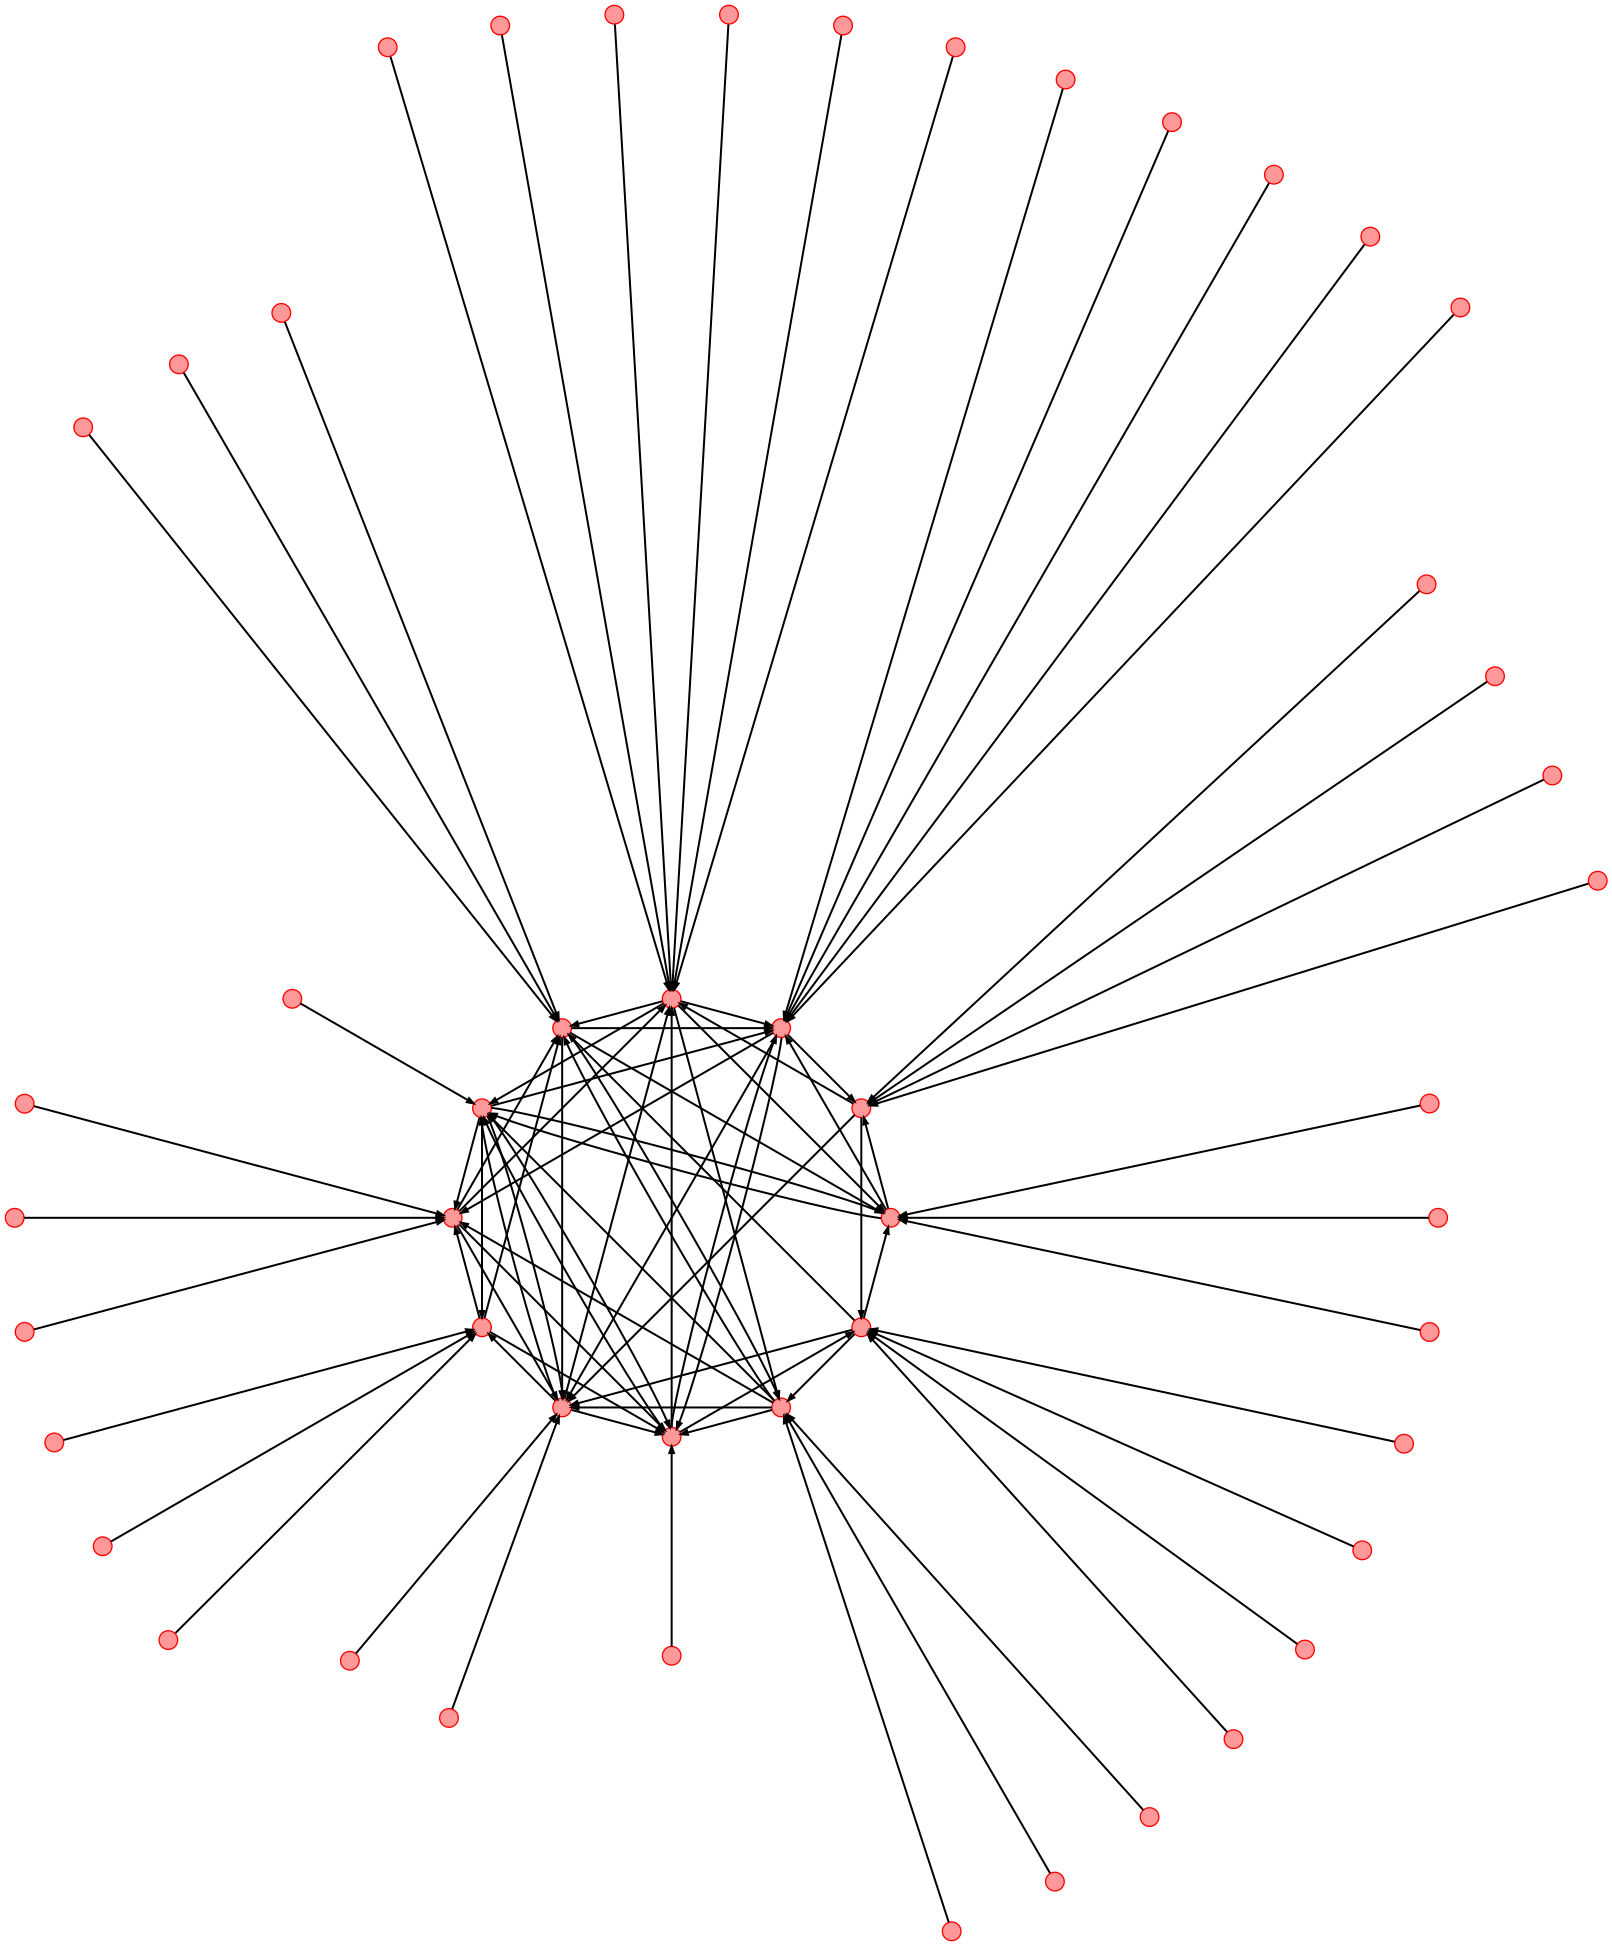

Saved as digraph.eps


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
import numpy as np
import networkx as nx
import pydot

# Path to adjacency file
file_path = "/content/drive/MyDrive/adjacency.csv"

# Load adjacency matrix
adj_matrix = np.loadtxt(file_path, delimiter=",")

# Create directed graph
G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

# Convert to pydot graph
P = nx.drawing.nx_pydot.to_pydot(G)

# Set circular layout
P.set_layout("circo")

# ---- Style Nodes ----
for node in P.get_nodes():
    node.set_shape("circle")
    node.set_style("filled")
    node.set_fillcolor("#ff9999")  # light red fill
    node.set_color("red")          # red border
    node.set_width("0.2")          # small size
    node.set_fixedsize("true")
    node.set_label("")             # remove labels

# ---- Style Edges ----
for edge in P.get_edges():
    edge.set_arrowsize("0.5")      # small arrow
    edge.set_penwidth("1.5")

# Save as EPS (journal-quality vector)
output_file = "digraph.eps"
P.write(output_file, format="eps")

print("Saved as", output_file)

# ---- Display in Colab ----
from IPython.display import Image, display
png_data = P.create_png()
display(Image(png_data))

# ---- Save as EPS (journal-quality vector) ----
output_file = "digraph.eps"
P.write(output_file, format="eps")

print("Saved as", output_file)

from google.colab import files
files.download(output_file)

In [36]:
import pandas as pd

df = pd.read_csv(adjacency_file)
df = df.iloc[1:]          # remove first row
df.to_csv("adjacency.csv", index=False)

print("First row removed.")

First row removed.
